In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
from google.colab import files
import sys
sys.path.insert(0,'/content/drive/MyDrive/Field_test')

In [19]:
import torch
import numpy as np
import scipy.io
import math
import matplotlib.pyplot as plt


In [20]:
# load mat file on hampton
AUV_1_traj_data = scipy.io.loadmat('/content/drive/MyDrive/Field_test/hampton_data_post_processing/AUV_A_locArray_1.mat')
AUV_2_traj_data = scipy.io.loadmat('/content/drive/MyDrive/Field_test/hampton_data_post_processing/AUV_B_locArray_1.mat')
AUV_3_traj_data = scipy.io.loadmat('/content/drive/MyDrive/Field_test/hampton_data_post_processing/AUV_C_locArray_1.mat')


In [21]:
AUV_1_traj = AUV_1_traj_data['AUV_A_locArray']
AUV_2_traj = AUV_2_traj_data['AUV_B_locArray']
AUV_3_traj = AUV_3_traj_data['AUV_C_locArray']

AUV_1_XY = AUV_1_traj[:,:2]
AUV_2_XY = AUV_2_traj[:,:2]
AUV_3_XY = AUV_3_traj[:,:2]

In [22]:
def change_coordiates_2D(arr, x,y):
  return arr + np.array([x, y])

def change_coordiates_4D(arr, x,y):
  return arr + np.array([x, y,x,y])


# hampton offset for 3 agents data 1
n_offset = -1214315
e_offset = 4955512

traj_1_post = change_coordiates_2D(AUV_1_XY, n_offset, e_offset)
traj_2_post = change_coordiates_2D(AUV_2_XY, n_offset, e_offset)
traj_3_post = change_coordiates_2D(AUV_3_XY, n_offset, e_offset)

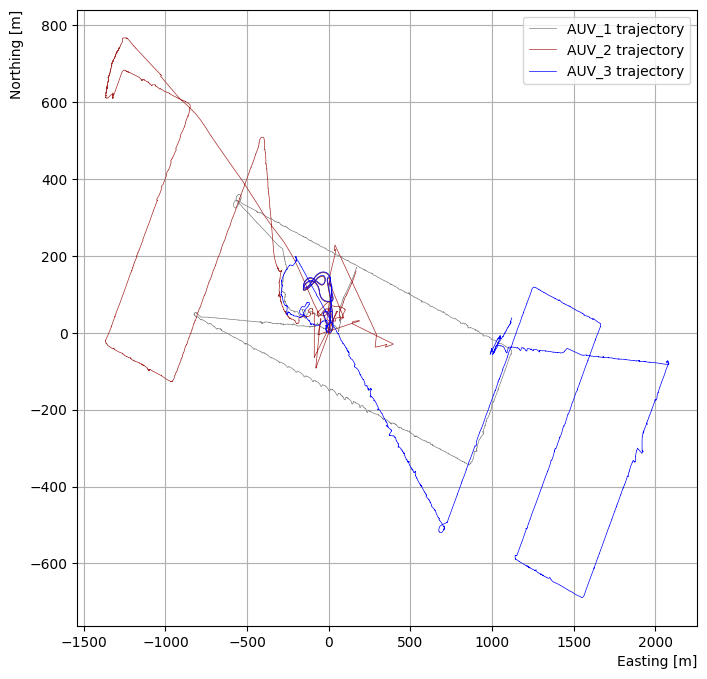

In [23]:
# plot AUV trajectories
fig, ax = plt.subplots(figsize = (8,8))
plt.plot(traj_1_post[:,0], traj_1_post[:,1], label = "AUV_1 trajectory", linewidth = 0.5, color = 'grey',alpha = 1.0)
plt.plot(traj_2_post[:,0], traj_2_post[:,1], label = "AUV_2 trajectory", linewidth = 0.5, color = 'brown',alpha = 1.0)
plt.plot(traj_3_post[:,0], traj_3_post[:,1], label = "AUV_3 trajectory", linewidth = 0.5, color = 'blue',alpha = 1.0)
ax.set_xlabel("Easting [m]", loc = 'right')
ax.set_ylabel("Northing [m]", loc = 'top')

plt.legend()
plt.grid()

# save
plt.savefig('AUV_trajectories_three_agents.png')

In [24]:
from re import A

# post-process acomms data on hampton
A_send_B_rece_suc = scipy.io.loadmat('/content/drive/MyDrive/Field_test/hampton_data_post_processing/A_send_B_rece_suc_pack_1.mat')
A_send_B_rece_unsuc = scipy.io.loadmat('/content/drive/MyDrive/Field_test/hampton_data_post_processing/A_send_B_rece_unsuc_pack_1.mat')
A_send_C_rece_suc = scipy.io.loadmat('/content/drive/MyDrive/Field_test/hampton_data_post_processing/A_send_C_rece_suc_pack_1.mat')
A_send_C_rece_unsuc = scipy.io.loadmat('/content/drive/MyDrive/Field_test/hampton_data_post_processing/A_send_C_rece_unsuc_pack_1.mat')

B_send_A_rece_suc = scipy.io.loadmat('/content/drive/MyDrive/Field_test/hampton_data_post_processing/B_send_A_rece_suc_pack_1.mat')
B_send_A_rece_unsuc = scipy.io.loadmat('/content/drive/MyDrive/Field_test/hampton_data_post_processing/B_send_A_rece_unsuc_pack_1.mat')
B_send_C_rece_suc = scipy.io.loadmat('/content/drive/MyDrive/Field_test/hampton_data_post_processing/B_send_C_rece_suc_pack_1.mat')
B_send_C_rece_unsuc = scipy.io.loadmat('/content/drive/MyDrive/Field_test/hampton_data_post_processing/B_send_C_rece_unsuc_pack_1.mat')

C_send_A_rece_suc = scipy.io.loadmat('/content/drive/MyDrive/Field_test/hampton_data_post_processing/C_send_A_rece_suc_pack_1.mat')
C_send_A_rece_unsuc = scipy.io.loadmat('/content/drive/MyDrive/Field_test/hampton_data_post_processing/C_send_A_rece_unsuc_pack_1.mat')
C_send_B_rece_suc = scipy.io.loadmat('/content/drive/MyDrive/Field_test/hampton_data_post_processing/C_send_B_rece_suc_pack_1.mat')
C_send_B_rece_unsuc = scipy.io.loadmat('/content/drive/MyDrive/Field_test/hampton_data_post_processing/C_send_B_rece_unsuc_pack_1.mat')


# 690-1 data
B_send_A_rece_suc = B_send_A_rece_suc['B_send_A_rece_suc_pack']
B_send_A_rece_unsuc = B_send_A_rece_unsuc['B_send_A_rece_unsuc_pack']
C_send_A_rece_suc = C_send_A_rece_suc['C_send_A_rece_suc_pack']
C_send_A_rece_unsuc = C_send_A_rece_unsuc['C_send_A_rece_unsuc_pack']

# 690-2 data
A_send_B_rece_suc = A_send_B_rece_suc['A_send_B_rece_suc_pack']
A_send_B_rece_unsuc = A_send_B_rece_unsuc['A_send_B_rece_unsuc_pack']
C_send_B_rece_suc = C_send_B_rece_suc['C_send_B_rece_suc_pack']
C_send_B_rece_unsuc = C_send_B_rece_unsuc['C_send_B_rece_unsuc_pack']

# 690-4 data
A_send_C_rece_suc = A_send_C_rece_suc['A_send_C_rece_suc_pack']
A_send_C_rece_unsuc = A_send_C_rece_unsuc['A_send_C_rece_unsuc_pack']
B_send_C_rece_suc = B_send_C_rece_suc['B_send_C_rece_suc_pack']
B_send_C_rece_unsuc = B_send_C_rece_unsuc['B_send_C_rece_unsuc_pack']


# # post-process acomms data on Claytor
# # 690-1 data
# B_send_A_rece_suc, B_send_A_rece_unsuc = extract_suc_unsuc_data(sequential_BSD_B_to_A)
# C_send_A_rece_suc, C_send_A_rece_unsuc = extract_suc_unsuc_data(sequential_BSD_C_to_A)

# # 690-2 data
# A_send_B_rece_suc, A_send_B_rece_unsuc = extract_suc_unsuc_data(sequential_BSD_A_to_B)
# C_send_B_rece_suc, C_send_B_rece_unsuc = extract_suc_unsuc_data(sequential_BSD_C_to_B)

# # 690-3 data
# A_send_C_rece_suc, A_send_C_rece_unsuc = extract_suc_unsuc_data(sequential_BSD_A_to_C)
# B_send_C_rece_suc, B_send_C_rece_unsuc = extract_suc_unsuc_data(sequential_BSD_B_to_C)



# # only needed for claytor lake data
# B_send_A_rece_suc = np.hstack((
#     B_send_A_rece_suc[:, :1],  # First column
#     np.zeros((B_send_A_rece_suc.shape[0], 1)),  # Dummy column
#     B_send_A_rece_suc[:, 1:]   # Rest of the columns
# ))

# C_send_A_rece_suc = np.hstack((
#     C_send_A_rece_suc[:, :1],  # First column
#     np.zeros((C_send_A_rece_suc.shape[0], 1)),
#     C_send_A_rece_suc[:, 1:]   # Rest of the columns
# ))


# # add dummy for 690-2 suc data
# A_send_B_rece_suc = np.hstack((
#     A_send_B_rece_suc[:, :1],  # First column
#     np.zeros((A_send_B_rece_suc.shape[0], 1)),  # Dummy column
#     A_send_B_rece_suc[:, 1:]   # Rest of the columns
# ))

# C_send_B_rece_suc = np.hstack((
#     C_send_B_rece_suc[:, :1],  # First column
#     np.zeros((C_send_B_rece_suc.shape[0], 1)),
#     C_send_B_rece_suc[:,1:]
# ))

# # add dummy for 690-3 suc data
# A_send_C_rece_suc = np.hstack((
#     A_send_C_rece_suc[:, :1],  # First column
#     np.zeros((A_send_C_rece_suc.shape[0], 1)),
#     A_send_C_rece_suc[:, 1:]   # Rest of the columns
# ))

# B_send_C_rece_suc = np.hstack((
#     B_send_C_rece_suc[:, :1],  # First column
#     np.zeros((B_send_C_rece_suc.shape[0], 1)),
#     B_send_C_rece_suc[:, 1:]   # Rest of the columns
# ))


# add dummy for 690-1 unsuc data
B_send_A_rece_unsuc = np.hstack((
    B_send_A_rece_unsuc[:, :1],  # First column
    np.zeros((B_send_A_rece_unsuc.shape[0], 1)),  # Dummy column
    B_send_A_rece_unsuc[:, 1:]   # Rest of the columns
))

C_send_A_rece_unsuc = np.hstack((
    C_send_A_rece_unsuc[:, :1],  # First column
    np.zeros((C_send_A_rece_unsuc.shape[0], 1)),
    C_send_A_rece_unsuc[:, 1:]   # Rest of the columns
))


# add dummy for 690-2 unsuc data
A_send_B_rece_unsuc = np.hstack((
    A_send_B_rece_unsuc[:, :1],  # First column
    np.zeros((A_send_B_rece_unsuc.shape[0], 1)),  # Dummy column
    A_send_B_rece_unsuc[:, 1:]   # Rest of the columns
))

C_send_B_rece_unsuc = np.hstack((
    C_send_B_rece_unsuc[:, :1],  # First column
    np.zeros((C_send_B_rece_unsuc.shape[0], 1)),
    C_send_B_rece_unsuc[:,1:]
))

# add dummy for 690-3 unsuc data
A_send_C_rece_unsuc = np.hstack((
    A_send_C_rece_unsuc[:, :1],  # First column
    np.zeros((A_send_C_rece_unsuc.shape[0], 1)),
    A_send_C_rece_unsuc[:, 1:]   # Rest of the columns
))

B_send_C_rece_unsuc = np.hstack((
    B_send_C_rece_unsuc[:, :1],  # First column
    np.zeros((B_send_C_rece_unsuc.shape[0], 1)),
    B_send_C_rece_unsuc[:, 1:]   # Rest of the columns
))


# # processing hampton data
AUV_1_suc_gt_BA = np.concatenate([B_send_A_rece_suc[:,2:4], B_send_A_rece_suc[:,5:7]], axis = 1)
AUV_1_suc_gt_CA = np.concatenate([C_send_A_rece_suc[:,2:4], C_send_A_rece_suc[:,5:7]], axis = 1)
AUV_1_unsuc_gt_BA = np.concatenate([B_send_A_rece_unsuc[:,2:4], B_send_A_rece_unsuc[:,5:7]], axis = 1)
AUV_1_unsuc_gt_CA = np.concatenate([C_send_A_rece_unsuc[:,2:4], C_send_A_rece_unsuc[:,5:7]], axis = 1)
AUV_1_suc_gt = np.concatenate([AUV_1_suc_gt_BA, AUV_1_suc_gt_CA], axis = 0)
AUV_1_unsuc_gt = np.concatenate([AUV_1_unsuc_gt_BA, AUV_1_unsuc_gt_CA], axis = 0)

AUV_2_suc_gt_AB = np.concatenate([A_send_B_rece_suc[:,2:4], A_send_B_rece_suc[:,5:7]], axis = 1)
AUV_2_suc_gt_CB = np.concatenate([C_send_B_rece_suc[:,2:4], C_send_B_rece_suc[:,5:7]], axis = 1)
AUV_2_unsuc_gt_AB = np.concatenate([A_send_B_rece_unsuc[:,2:4], A_send_B_rece_unsuc[:,5:7]], axis = 1)
AUV_2_unsuc_gt_CB = np.concatenate([C_send_B_rece_unsuc[:,2:4], C_send_B_rece_unsuc[:,5:7]], axis = 1)
AUV_2_suc_gt = np.concatenate([AUV_2_suc_gt_AB, AUV_2_suc_gt_CB], axis = 0)
AUV_2_unsuc_gt = np.concatenate([AUV_2_unsuc_gt_AB, AUV_2_unsuc_gt_CB], axis = 0)


AUV_3_suc_gt_AC = np.concatenate([A_send_C_rece_suc[:,2:4], A_send_C_rece_suc[:,5:7]], axis = 1)
AUV_3_suc_gt_BC = np.concatenate([B_send_C_rece_suc[:,2:4], B_send_C_rece_suc[:,5:7]], axis = 1)
AUV_3_unsuc_gt_AC = np.concatenate([A_send_C_rece_unsuc[:,2:4], A_send_C_rece_unsuc[:,5:7]], axis = 1)
AUV_3_unsuc_gt_BC = np.concatenate([B_send_C_rece_unsuc[:,2:4], B_send_C_rece_unsuc[:,5:7]], axis = 1)
AUV_3_suc_gt = np.concatenate([AUV_3_suc_gt_AC, AUV_3_suc_gt_BC], axis = 0)
AUV_3_unsuc_gt = np.concatenate([AUV_3_unsuc_gt_AC, AUV_3_unsuc_gt_BC], axis = 0)


AUV_1_suc_gt_BA = change_coordiates_4D(AUV_1_suc_gt_BA, n_offset, e_offset)
AUV_1_unsuc_gt_BA = change_coordiates_4D(AUV_1_unsuc_gt_BA, n_offset, e_offset)
AUV_1_suc_gt_CA = change_coordiates_4D(AUV_1_suc_gt_CA, n_offset, e_offset)
AUV_1_unsuc_gt_CA = change_coordiates_4D(AUV_1_unsuc_gt_CA, n_offset, e_offset)

AUV_2_suc_gt_AB = change_coordiates_4D(AUV_2_suc_gt_AB, n_offset, e_offset)
AUV_2_unsuc_gt_AB = change_coordiates_4D(AUV_2_unsuc_gt_AB, n_offset, e_offset)
AUV_2_suc_gt_CB = change_coordiates_4D(AUV_2_suc_gt_CB, n_offset, e_offset)
AUV_2_unsuc_gt_CB = change_coordiates_4D(AUV_2_unsuc_gt_CB, n_offset, e_offset)

AUV_3_suc_gt_AC = change_coordiates_4D(AUV_3_suc_gt_AC, n_offset, e_offset)
AUV_3_unsuc_gt_AC = change_coordiates_4D(AUV_3_unsuc_gt_AC, n_offset, e_offset)
AUV_3_suc_gt_BC = change_coordiates_4D(AUV_3_suc_gt_BC, n_offset, e_offset)
AUV_3_unsuc_gt_BC = change_coordiates_4D(AUV_3_unsuc_gt_BC, n_offset, e_offset)


AUV_1_suc_gt = change_coordiates_4D(AUV_1_suc_gt, n_offset, e_offset)
AUV_1_unsuc_gt = change_coordiates_4D(AUV_1_unsuc_gt, n_offset, e_offset)
AUV_2_suc_gt = change_coordiates_4D(AUV_2_suc_gt, n_offset, e_offset)
AUV_2_unsuc_gt = change_coordiates_4D(AUV_2_unsuc_gt, n_offset, e_offset)
AUV_3_suc_gt = change_coordiates_4D(AUV_3_suc_gt, n_offset, e_offset)
AUV_3_unsuc_gt = change_coordiates_4D(AUV_3_unsuc_gt, n_offset, e_offset)

In [25]:
def remove_duplicates(X):
    # Combine X and y to track correspondence

    # Remove duplicates based on X features only (all columns except last)
    _, unique_indices = np.unique(X, axis=0, return_index=True)

    # Sort indices to maintain original order
    unique_indices = np.sort(unique_indices)

    # Return cleaned X and y
    return X[unique_indices]

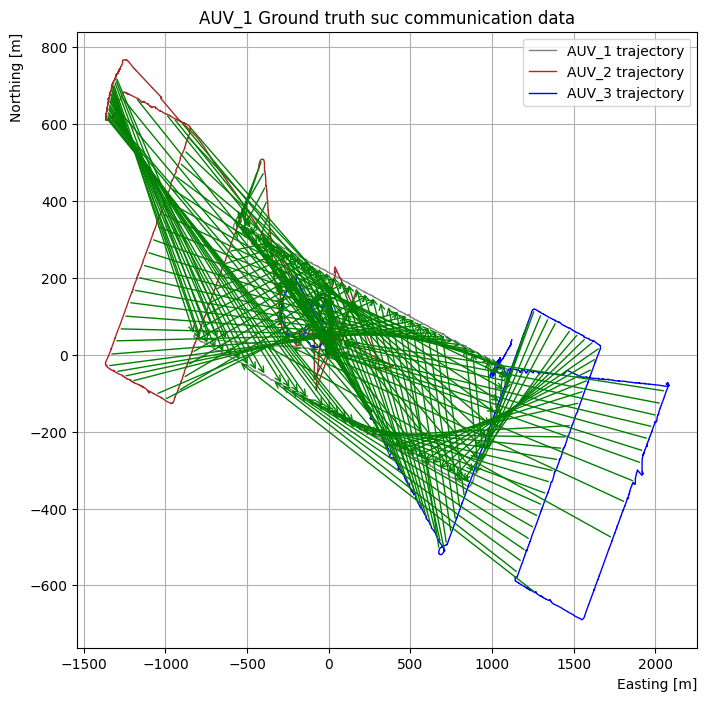

In [26]:
# plot 690-1 data
# plot true communications on vehicle 1
# plot AUV trajectories
fig, ax = plt.subplots(figsize = (8,8))
plt.plot(traj_1_post[:,0], traj_1_post[:,1], label = "AUV_1 trajectory", linewidth = 1.0, color = 'grey',alpha = 1.0)
plt.plot(traj_2_post[:,0], traj_2_post[:,1], label = "AUV_2 trajectory", linewidth = 1.0, color = 'brown',alpha = 1.0)
plt.plot(traj_3_post[:,0], traj_3_post[:,1], label = "AUV_3 trajectory", linewidth = 1.0, color = 'blue',alpha = 1.0)


for i in range(len(AUV_1_suc_gt)):
  plt.annotate('', xy=(AUV_1_suc_gt[i][2], AUV_1_suc_gt[i][3]), xytext=(AUV_1_suc_gt[i][0], AUV_1_suc_gt[i][1]), arrowprops=dict(linestyle = '-', linewidth = 1.0, color='green', arrowstyle='->'))
#for i in range(len(AUV_1_unsuc_gt)):
#  plt.annotate('', xy=(AUV_1_unsuc_gt[i][2], AUV_1_unsuc_gt[i][3]), xytext=(AUV_1_unsuc_gt[i][0], AUV_1_unsuc_gt[i][1]), arrowprops=dict(linestyle = '--', linewidth = 1.5, color='black', arrowstyle='->'))

ax.set_xlabel("Easting [m]", loc = 'right')
ax.set_ylabel("Northing [m]", loc = 'top')
plt.title("AUV_1 Ground truth suc communication data")
plt.legend()
plt.grid()
plt.savefig('AUV_1_suc_gt.png')

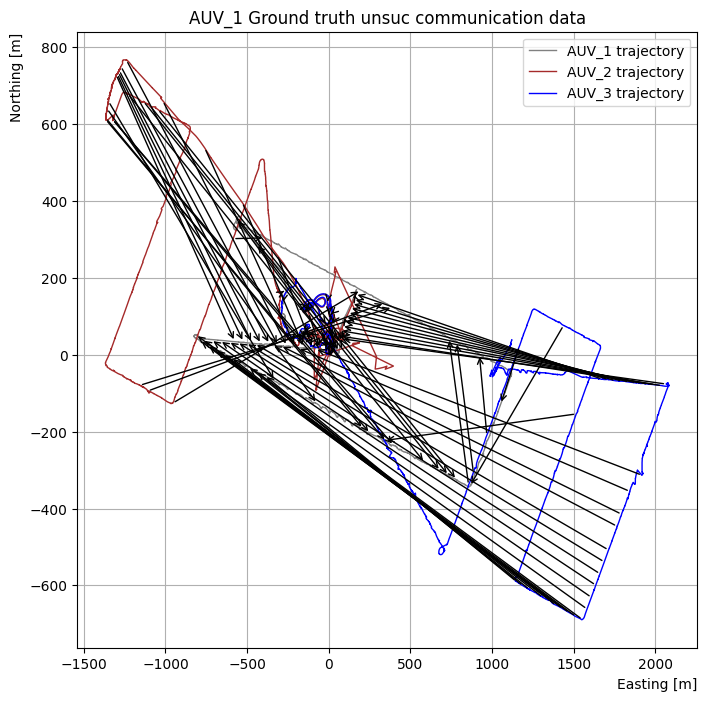

In [27]:
# plot 690-1 data
# plot true communications on vehicle 1
# plot AUV trajectories
fig, ax = plt.subplots(figsize = (8,8))
plt.plot(traj_1_post[:,0], traj_1_post[:,1], label = "AUV_1 trajectory", linewidth = 1.0, color = 'grey',alpha = 1.0)
plt.plot(traj_2_post[:,0], traj_2_post[:,1], label = "AUV_2 trajectory", linewidth = 1.0, color = 'brown',alpha = 1.0)
plt.plot(traj_3_post[:,0], traj_3_post[:,1], label = "AUV_3 trajectory", linewidth = 1.0, color = 'blue',alpha = 1.0)


for i in range(len(AUV_1_unsuc_gt)):
  plt.annotate('', xy=(AUV_1_unsuc_gt[i][2], AUV_1_unsuc_gt[i][3]), xytext=(AUV_1_unsuc_gt[i][0], AUV_1_unsuc_gt[i][1]), arrowprops=dict(linestyle = '-', linewidth = 1.0, color='black', arrowstyle='->'))

ax.set_xlabel("Easting [m]", loc = 'right')
ax.set_ylabel("Northing [m]", loc = 'top')
plt.title("AUV_1 Ground truth unsuc communication data")
plt.legend()
plt.grid()
plt.savefig('AUV_1_unsuc_gt.png')

/tmp/ipykernel_3655/923494431.py:17: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('AUV_2_suc_gt.png')


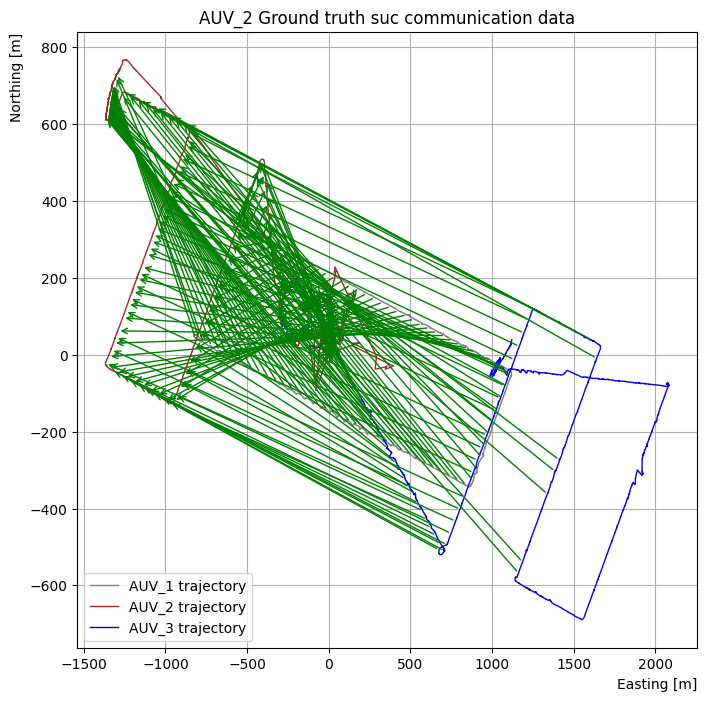

In [28]:
# plot 690-2 data
# plot AUV trajectories
fig, ax = plt.subplots(figsize = (8,8))
plt.plot(traj_1_post[:,0], traj_1_post[:,1], label = "AUV_1 trajectory", linewidth = 1.0, color = 'grey',alpha = 1.0)
plt.plot(traj_2_post[:,0], traj_2_post[:,1], label = "AUV_2 trajectory", linewidth = 1.0, color = 'brown',alpha = 1.0)
plt.plot(traj_3_post[:,0], traj_3_post[:,1], label = "AUV_3 trajectory", linewidth = 1.0, color = 'blue',alpha = 1.0)


for i in range(len(AUV_2_suc_gt)):
  plt.annotate('', xy=(AUV_2_suc_gt[i][2], AUV_2_suc_gt[i][3]), xytext=(AUV_2_suc_gt[i][0], AUV_2_suc_gt[i][1]), arrowprops=dict(linestyle = '-', linewidth = 1.0, color='green', arrowstyle='->'))

ax.set_xlabel("Easting [m]", loc = 'right')
ax.set_ylabel("Northing [m]", loc = 'top')
plt.title("AUV_2 Ground truth suc communication data")
plt.legend()
plt.grid()
plt.savefig('AUV_2_suc_gt.png')

/tmp/ipykernel_3655/2711442336.py:17: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('AUV_2_unsuc_gt.png')


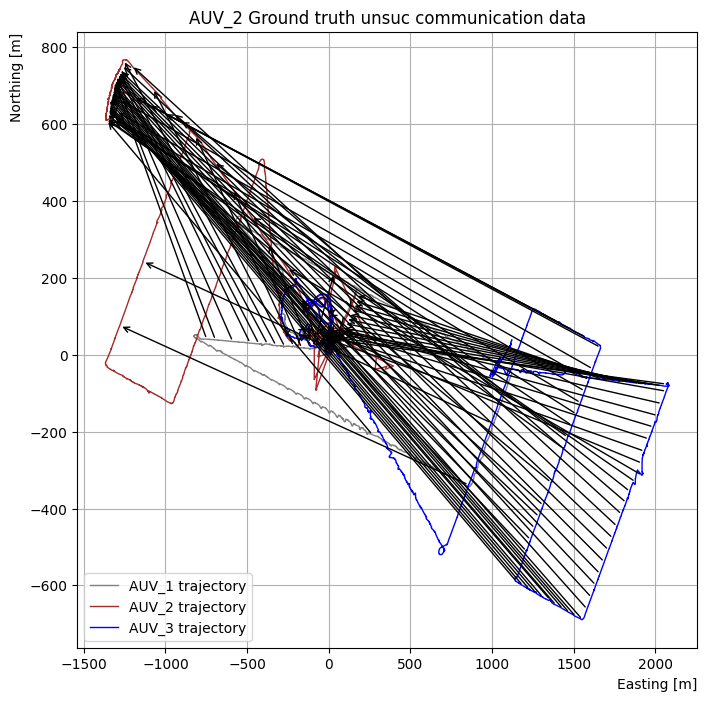

In [29]:
# plot 690-2 data
# plot AUV trajectories
fig, ax = plt.subplots(figsize = (8,8))
plt.plot(traj_1_post[:,0], traj_1_post[:,1], label = "AUV_1 trajectory", linewidth = 1.0, color = 'grey',alpha = 1.0)
plt.plot(traj_2_post[:,0], traj_2_post[:,1], label = "AUV_2 trajectory", linewidth = 1.0, color = 'brown',alpha = 1.0)
plt.plot(traj_3_post[:,0], traj_3_post[:,1], label = "AUV_3 trajectory", linewidth = 1.0, color = 'blue',alpha = 1.0)


for i in range(len(AUV_2_unsuc_gt)):
 plt.annotate('', xy=(AUV_2_unsuc_gt[i][2], AUV_2_unsuc_gt[i][3]), xytext=(AUV_2_unsuc_gt[i][0], AUV_2_unsuc_gt[i][1]), arrowprops=dict(linestyle = '-', linewidth = 1.0, color='black', arrowstyle='->'))

ax.set_xlabel("Easting [m]", loc = 'right')
ax.set_ylabel("Northing [m]", loc = 'top')
plt.title("AUV_2 Ground truth unsuc communication data")
plt.legend()
plt.grid()
plt.savefig('AUV_2_unsuc_gt.png')

/tmp/ipykernel_3655/632470095.py:17: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('AUV_3_suc_gt.png')


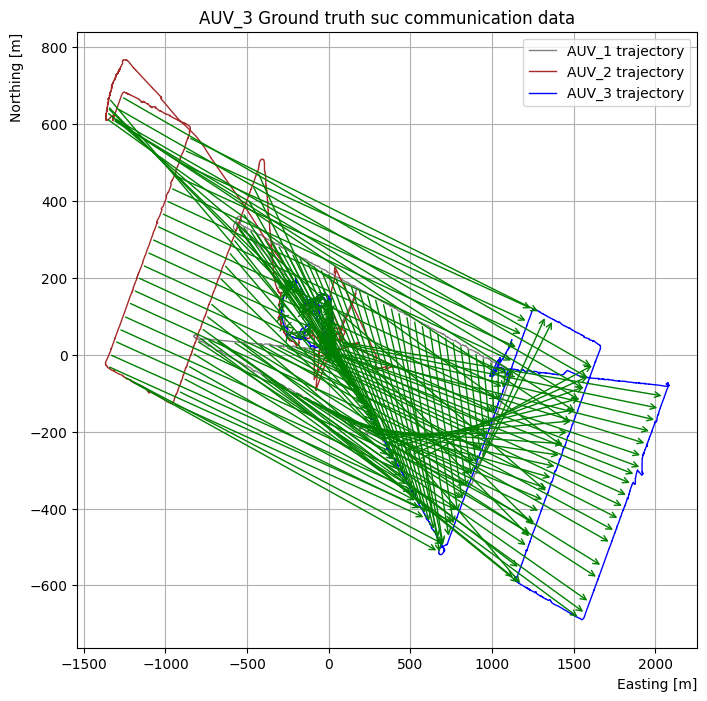

In [30]:
# plot 690-3 data
# plot AUV trajectories
fig, ax = plt.subplots(figsize = (8,8))
plt.plot(traj_1_post[:,0], traj_1_post[:,1], label = "AUV_1 trajectory", linewidth = 1.0, color = 'grey',alpha = 1.0)
plt.plot(traj_2_post[:,0], traj_2_post[:,1], label = "AUV_2 trajectory", linewidth = 1.0, color = 'brown',alpha = 1.0)
plt.plot(traj_3_post[:,0], traj_3_post[:,1], label = "AUV_3 trajectory", linewidth = 1.0, color = 'blue',alpha = 1.0)


for i in range(len(AUV_3_suc_gt)):
  plt.annotate('', xy=(AUV_3_suc_gt[i][2], AUV_3_suc_gt[i][3]), xytext=(AUV_3_suc_gt[i][0], AUV_3_suc_gt[i][1]), arrowprops=dict(linestyle = '-', linewidth = 1.0, color='green', arrowstyle='->'))

ax.set_xlabel("Easting [m]", loc = 'right')
ax.set_ylabel("Northing [m]", loc = 'top')
plt.title("AUV_3 Ground truth suc communication data")
plt.legend()
plt.grid()
plt.savefig('AUV_3_suc_gt.png')

/tmp/ipykernel_3655/2211567909.py:17: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('AUV_3_unsuc_gt.png')


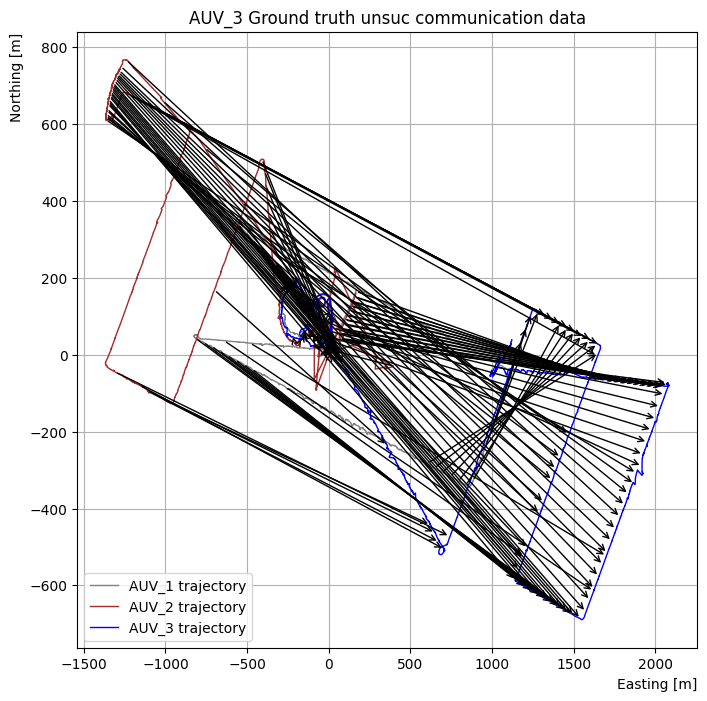

In [31]:
# plot 690-3 data
# plot AUV trajectories
fig, ax = plt.subplots(figsize = (8,8))
plt.plot(traj_1_post[:,0], traj_1_post[:,1], label = "AUV_1 trajectory", linewidth = 1.0, color = 'grey',alpha = 1.0)
plt.plot(traj_2_post[:,0], traj_2_post[:,1], label = "AUV_2 trajectory", linewidth = 1.0, color = 'brown',alpha = 1.0)
plt.plot(traj_3_post[:,0], traj_3_post[:,1], label = "AUV_3 trajectory", linewidth = 1.0, color = 'blue',alpha = 1.0)


for i in range(len(AUV_3_unsuc_gt)):
 plt.annotate('', xy=(AUV_3_unsuc_gt[i][2], AUV_3_unsuc_gt[i][3]), xytext=(AUV_3_unsuc_gt[i][0], AUV_3_unsuc_gt[i][1]), arrowprops=dict(linestyle = '-', linewidth = 1.0, color='black', arrowstyle='->'))

ax.set_xlabel("Easting [m]", loc = 'right')
ax.set_ylabel("Northing [m]", loc = 'top')
plt.title("AUV_3 Ground truth unsuc communication data")
plt.legend()
plt.grid()
plt.savefig('AUV_3_unsuc_gt.png')